In [7]:
import torch
from train import train
from lofi_model import LofiModel
from dataset import MidiDataset
import pretty_midi
import numpy as np
from config import *
print(torch.__version__)
print(torch.version.cuda)

2.7.1+cu118
11.8


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model = LofiModel()
model.load_state_dict(torch.load('./saved_models/best_models/Drumms-only small Dataset SMALLER MODEL.pth'))
model.to(device)
model.eval()

LofiModel(
  (encoder): Encoder(
    (lstm): LSTM(76, 64, num_layers=2, batch_first=True, bidirectional=True)
    (fc_mean): Linear(in_features=128, out_features=64, bias=True)
    (fc_logvar): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (lstm): LSTM(76, 64, num_layers=2, batch_first=True)
    (fc): Linear(in_features=64, out_features=76, bias=True)
  )
  (fc_latent_to_hidden): Linear(in_features=64, out_features=128, bias=True)
  (fc_latent_to_cell): Linear(in_features=64, out_features=128, bias=True)
)

## Reconstruction

In [9]:
dataset_dir = r"C:\Users\Hyperbook\Desktop\STUDIA\SEM III\PROJEKT ZESPOLOWY\dataset\golden_dataset\all_songs"
dataset = MidiDataset(dataset_dir, verbose=True)

Processing file: 01ffb8729a2465bfa7f9ba0288c89e24
Original sequence:


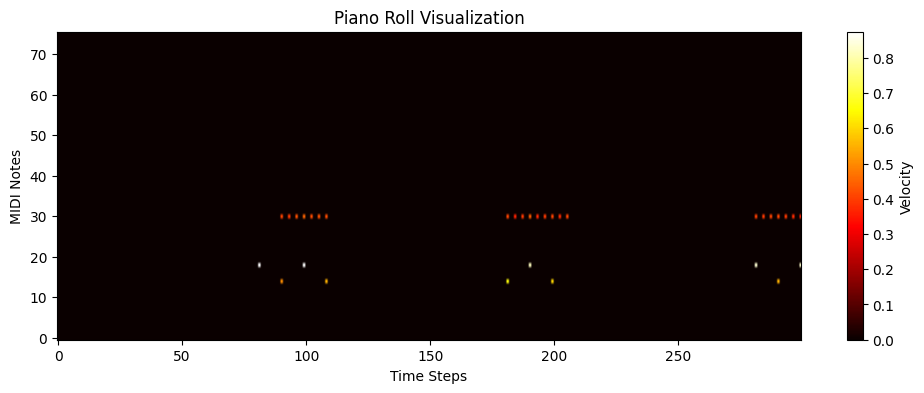

Reconstruction:


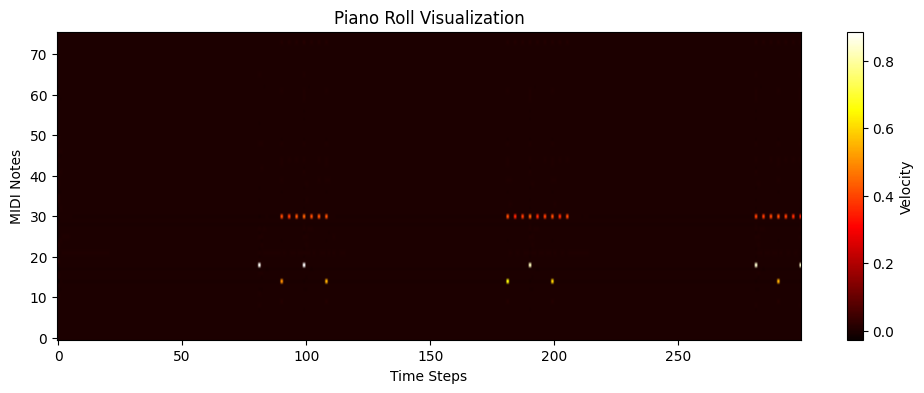

________________________________________________________________________________________________________________________

Processing file: 0435c5ba618a4e13d66e233b900aa7c5
Original sequence:


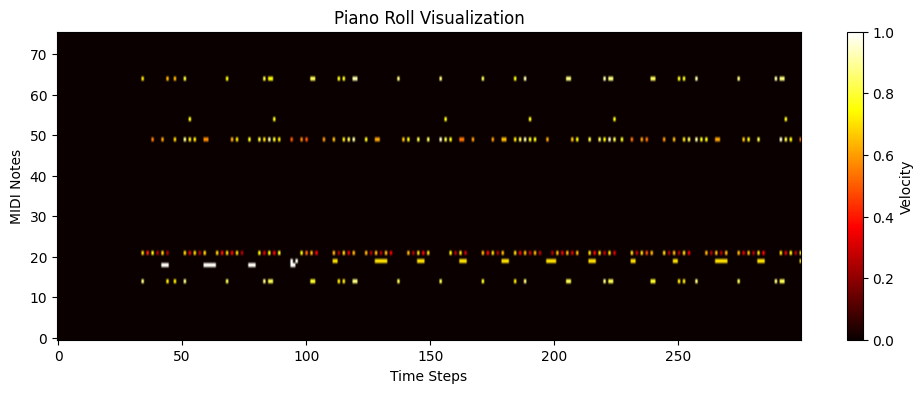

Reconstruction:


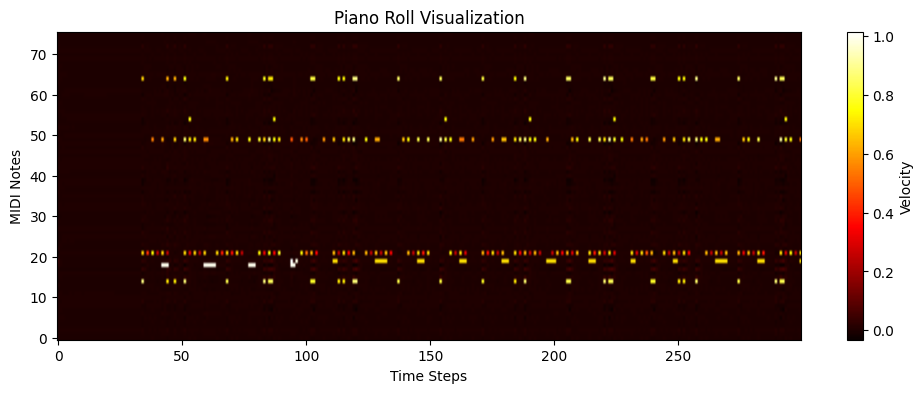

________________________________________________________________________________________________________________________

Processing file: 05f21994c71a5f881e64f45c8d706165
Original sequence:


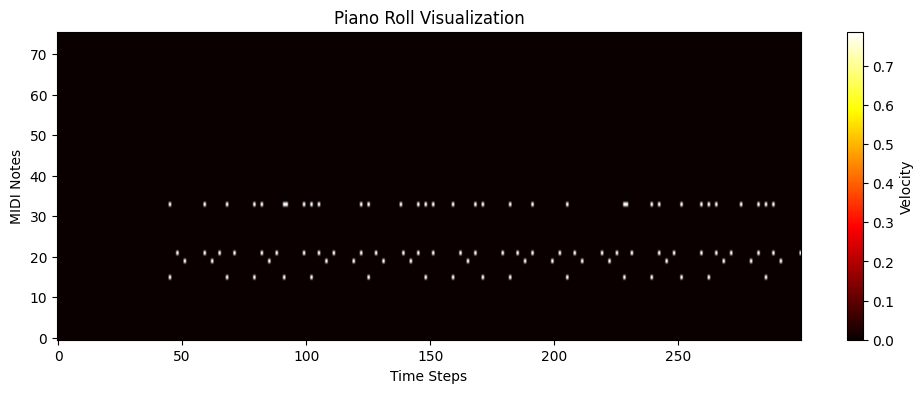

Reconstruction:


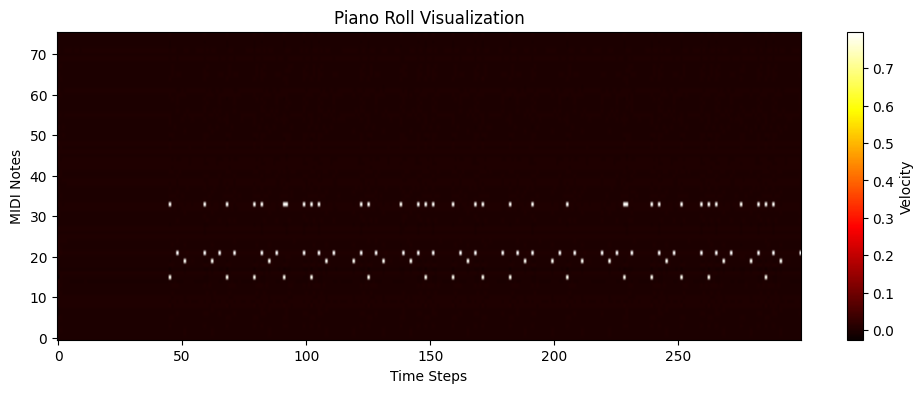

________________________________________________________________________________________________________________________

Processing file: 10288ea8e07b70c17f872fda82b94330
Original sequence:


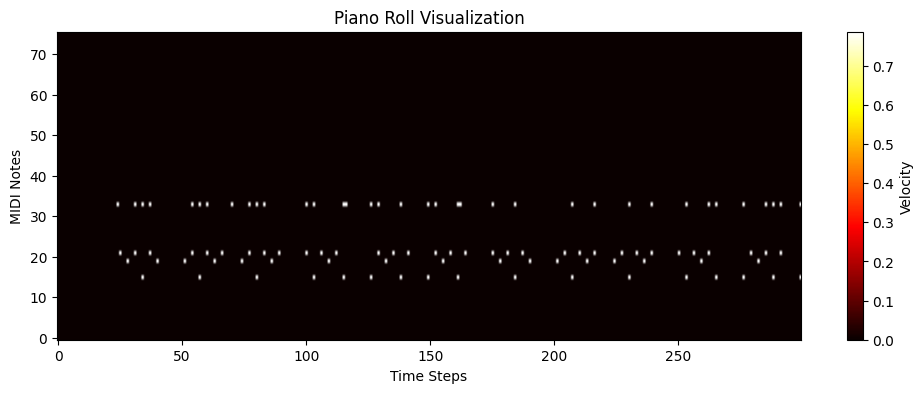

Reconstruction:


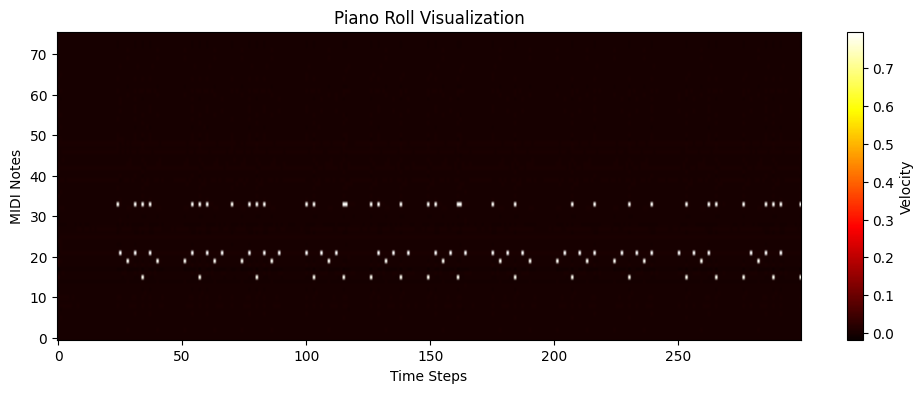

________________________________________________________________________________________________________________________

Processing file: 107e4bc3d4ba312c14fcd0b82d7eb663
Original sequence:


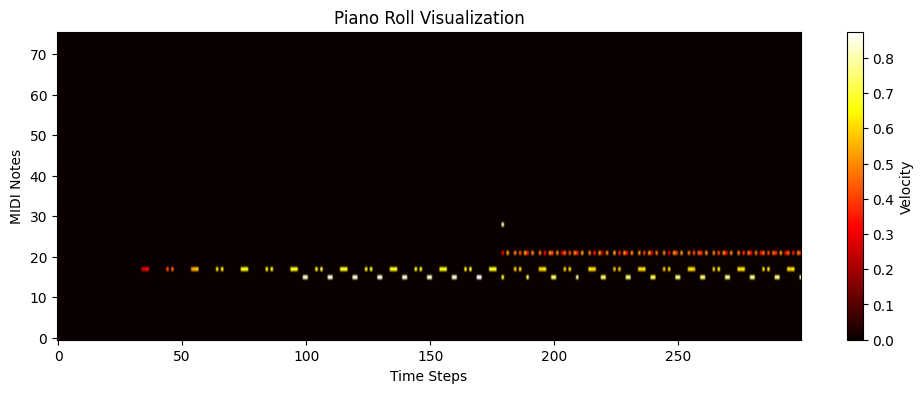

Reconstruction:


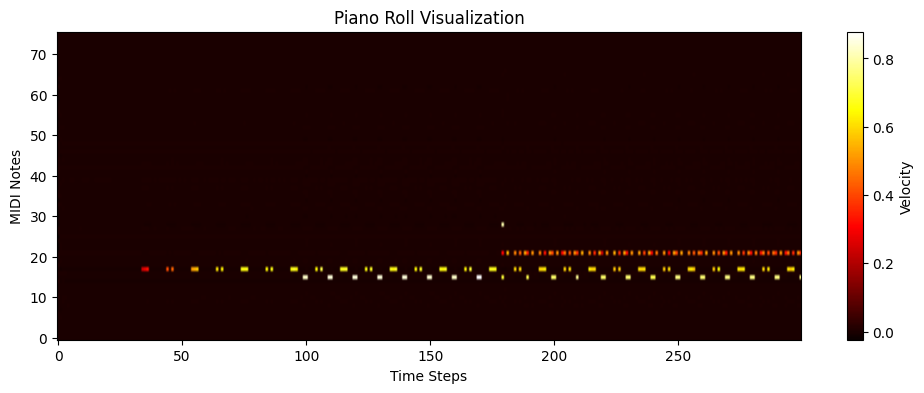

________________________________________________________________________________________________________________________



In [10]:
for i in range(5):
    original_sequence_tensor, original_length_val, filename = dataset[i]
    print(f"Processing file: {filename}")
    print(f"Original sequence:")
    dataset.visualize_midi(original_sequence_tensor)
    print(f"Reconstruction:")
    reconstructions = model.reconstruct(original_sequence_tensor, original_length_val)
    print(60*"__"+"\n")